In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Understanding Data

In [2]:
df = pd.read_csv("../data/bank_transactions.csv")
df.head()

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR)
0,T1,C5841053,10/1/94,F,JAMSHEDPUR,17819.05,2/8/16,143207,25.0
1,T2,C2142763,4/4/57,M,JHAJJAR,2270.69,2/8/16,141858,27999.0
2,T3,C4417068,26/11/96,F,MUMBAI,17874.44,2/8/16,142712,459.0
3,T4,C5342380,14/9/73,F,MUMBAI,866503.21,2/8/16,142714,2060.0
4,T5,C9031234,24/3/88,F,NAVI MUMBAI,6714.43,2/8/16,181156,1762.5


In [3]:
# Check the shape of the dataset
print(f"The dataset has {df.shape[0]} rows and {df.shape[1]} columns.")

The dataset has 1048567 rows and 9 columns.


In [4]:
# Column names
df.columns

Index(['TransactionID', 'CustomerID', 'CustomerDOB', 'CustGender',
       'CustLocation', 'CustAccountBalance', 'TransactionDate',
       'TransactionTime', 'TransactionAmount (INR)'],
      dtype='str')

In [5]:
# Data information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1048567 entries, 0 to 1048566
Data columns (total 9 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   TransactionID            1048567 non-null  str    
 1   CustomerID               1048567 non-null  str    
 2   CustomerDOB              1045170 non-null  str    
 3   CustGender               1047467 non-null  str    
 4   CustLocation             1048416 non-null  str    
 5   CustAccountBalance       1046198 non-null  float64
 6   TransactionDate          1048567 non-null  str    
 7   TransactionTime          1048567 non-null  int64  
 8   TransactionAmount (INR)  1048567 non-null  float64
dtypes: float64(2), int64(1), str(6)
memory usage: 72.0 MB


In [6]:
# Statistical summary of the dataset
df.describe()

,CustAccountBalance,TransactionTime,TransactionAmount (INR)
count,1.046198e+06,1.048567e+06,1.048567e+06
mean,1.154035e+05,1.570875e+05,1.574335e+03
std,8.464854e+05,5.126185e+04,6.574743e+03
min,0.000000e+00,0.000000e+00,0.000000e+00
25%,4.721760e+03,1.240300e+05,1.610000e+02
50%,1.679218e+04,1.642260e+05,4.590300e+02
75%,5.765736e+04,2.000100e+05,1.200000e+03
max,1.150355e+08,2.359590e+05,1.560035e+06


In [7]:
# Check for missing values
df.isnull().sum()

TransactionID                 0
CustomerID                    0
CustomerDOB                3397
CustGender                 1100
CustLocation                151
CustAccountBalance         2369
TransactionDate               0
TransactionTime               0
TransactionAmount (INR)       0
dtype: int64

## Insights
* The dataset has 1048567 rows and 9 columns.
* CustomerDOB and TransactionDate are stored as string (must be datetime())
* CustomerDOB, CustGender, CustLocation and CustAccountBalance have missing values

# Data Preprocessing

In [8]:
# Convert 'CustomerDOB' and 'TransactionDate' to datetime format
df['CustomerDOB'] = pd.to_datetime(df['CustomerDOB'], errors='coerce')
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'], errors='coerce')

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1048567 entries, 0 to 1048566
Data columns (total 9 columns):
 #   Column                   Non-Null Count    Dtype         
---  ------                   --------------    -----         
 0   TransactionID            1048567 non-null  str           
 1   CustomerID               1048567 non-null  str           
 2   CustomerDOB              1045170 non-null  datetime64[us]
 3   CustGender               1047467 non-null  str           
 4   CustLocation             1048416 non-null  str           
 5   CustAccountBalance       1046198 non-null  float64       
 6   TransactionDate          1048567 non-null  datetime64[us]
 7   TransactionTime          1048567 non-null  int64         
 8   TransactionAmount (INR)  1048567 non-null  float64       
dtypes: datetime64[us](2), float64(2), int64(1), str(4)
memory usage: 72.0 MB


In [10]:
new_df = df.copy()

In [11]:
# Check the range of birth years
new_df['Age'] = (pd.Timestamp.today() - new_df['CustomerDOB']).dt.days/365
new_df['Age'].describe()

count    1.045170e+06
mean     3.991466e+01
std      5.167678e+01
min     -4.961096e+01
25%      3.361918e+01
50%      3.732877e+01
75%      4.222466e+01
max      2.265699e+02
Name: Age, dtype: float64

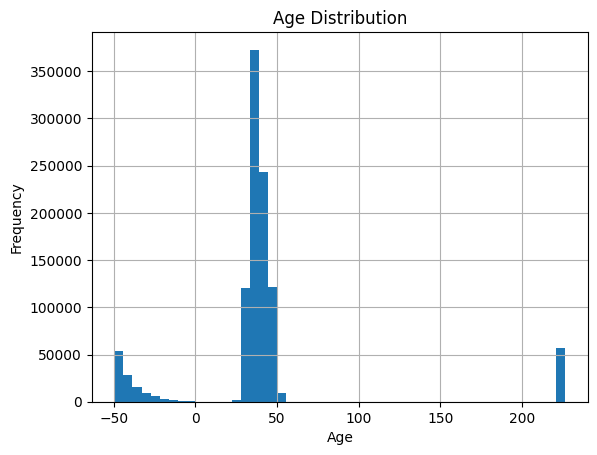

In [12]:
new_df['Age'].hist(bins=50)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

In [13]:
invalid_age = new_df[(new_df['Age'] < 18) | (new_df['Age'] > 100)]

print("Invalid ages:", len(invalid_age))
print("Percentage:", len(invalid_age)/len(df)*100)

Invalid ages: 175059
Percentage: 16.69507051051578


In [14]:
new_df.loc[(new_df['Age'] < 18) | (new_df['Age'] > 100), 'Age'] = np.nan

In [15]:
new_df['Age'].fillna(new_df['Age'].median(), inplace=True)

0          31.693151
1          37.789041
2          29.536986
3          37.789041
4          38.219178
             ...    
1048562    35.854795
1048563    34.306849
1048564    37.068493
1048565    47.791781
1048566    42.112329
Name: Age, Length: 1048567, dtype: float64

In [16]:
new_df.isnull().sum()

TransactionID                   0
CustomerID                      0
CustomerDOB                  3397
CustGender                   1100
CustLocation                  151
CustAccountBalance           2369
TransactionDate                 0
TransactionTime                 0
TransactionAmount (INR)         0
Age                        178456
dtype: int64